# How much alternative splicing GTEx and TCGA miss

GTEx hypothalamus (102 samples, 10-236M reads) and TCGA breast cancer (100
samples, 82-189M reads) are extrapolated to higher depth in three ways:

* blue, a degree-1 fit to the real cohort;
* orange, a degree-2 fit to the real cohort;
* green, a degree-2 fit to the downsampling series of the single deepest
  sample, which is the only curve anchored in observations above 200M.

The baseline (black horizontal line) is the green curve evaluated at the
typical depth of the cohort: the mean for GTEx, the median for TCGA. All
inputs are in `data/derived/extrapolation_counts/` and the notebook runs in seconds.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Locate the top of the clone, so the notebook runs from any directory inside it.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "asdepth").is_dir()), None)
if ROOT is None:
    raise RuntimeError("run this from inside a clone of RNA-Seq_Depth_for_AS")
sys.path.insert(0, str(ROOT))
from asdepth import millions, read_depth_counts, thousands

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

DATA = ROOT / "data" / "derived" / "extrapolation_counts"

# Depths at which the fitted curves are drawn.
GRID = np.array([10, 25, 50, 100, 150, 200, 250]) * 1_000_000

COLORS = {"linear": "#1E88E5", "quadratic": "orange", "downsampled": "#004D40"}

In [2]:
def polynomial_regression(x, y, order, confidence=95, points=100):
    """Fitted curve and its pointwise confidence band."""
    level = 1 - ((1 - confidence / 100) / 2)
    model = np.polyval(np.polyfit(x, y, order), x)
    residual = y - model
    dof = x.size - 2
    t = stats.t.ppf(level, dof)
    standard_error = (np.sum(residual ** 2) / dof) ** 0.5

    line_x = np.linspace(np.min(x), np.max(x), points)
    line_y = np.polyval(np.polyfit(x, y, order), line_x)
    interval = (
        t
        * standard_error
        * (1 / x.size + (line_x - np.mean(x)) ** 2 / np.sum((x - np.mean(x)) ** 2))
        ** 0.5
    )
    return line_x, line_y, interval


def evaluate(coefficients, quadratic):
    """Fitted values on GRID.

    The quadratic fits are only trusted as far as 200M, the deepest point the
    downsampling series reaches, so they are held flat beyond it rather than
    extrapolated. The linear fit runs the full range.
    """
    grid = GRID.copy()
    if quadratic:
        grid[-1] = grid[-2]
    return np.poly1d(coefficients)(grid)


def panel(axes, estimate, real, kind, title, baseline_statistic):
    axes.xaxis.set_major_formatter(plt.FuncFormatter(millions))
    axes.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
    axes.set_facecolor("white")
    axes.patch.set_edgecolor("black")
    axes.patch.set_linewidth(2)

    axes.scatter(
        real["depth_unique"], real["count"],
        c="white", s=100, edgecolors="black", linewidth=2,
    )

    fits = {}
    for order, name in ((1, "linear"), (2, "quadratic")):
        coefficients = np.polyfit(real["depth_unique"], real["count"], order)
        line_x, line_y, interval = polynomial_regression(
            real["depth_unique"], real["count"], order
        )
        grid_y = evaluate(coefficients, quadratic=(order == 2))
        axes.plot(GRID, grid_y, c=COLORS[name], linestyle="--", linewidth=5)
        axes.fill_between(line_x, line_y - interval, line_y + interval, alpha=0.5)
        fits[name] = grid_y

    downsampled = np.polyfit(estimate["depth"], estimate["count"], 2)
    fits["downsampled"] = evaluate(downsampled, quadratic=True)
    axes.plot(GRID, fits["downsampled"], c=COLORS["downsampled"],
              linestyle="--", linewidth=5)

    # Baseline: the downsampling curve at the typical depth of the cohort.
    depth = getattr(real["depth_unique"], baseline_statistic)()
    baseline = np.poly1d(downsampled)(depth)
    axes.hlines(baseline, 0, GRID[-1], colors="black")
    axes.vlines(200_000_000, 0, axes.get_ylim()[1], linestyles="--", colors="black")

    axes.set_ylabel(f"# of {kind}", size=22)
    axes.set_title(title, size=22)
    axes.tick_params(labelsize=16)
    axes.set_ylim(0)
    axes.set_xlim(0, GRID[-1])

    at_200m = {name: values[GRID == 200_000_000][0] for name, values in fits.items()}
    return baseline, at_200m

## The four panels

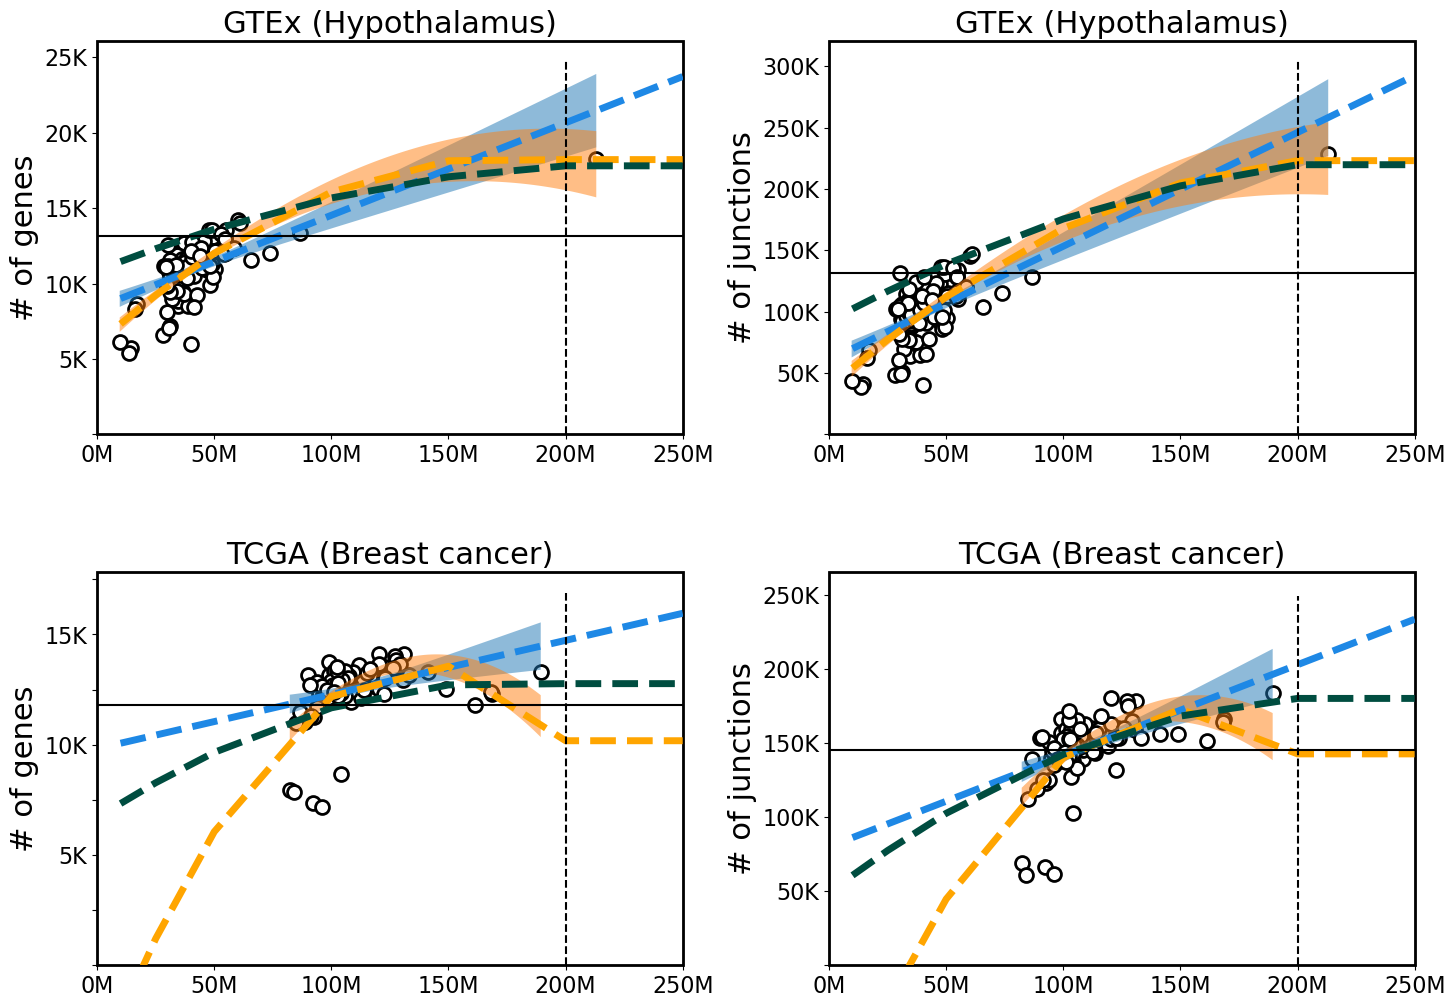

In [3]:
COHORTS = [
    ("GTEx (Hypothalamus)", "hypo", "gtex", "mean"),
    ("TCGA (Breast cancer)", "tcga_est", "tcga", "median"),
]

figure, axes_grid = plt.subplots(2, 2, figsize=(17, 12))
figure.subplots_adjust(hspace=0.35, wspace=0.25)

reported = []
for row, (title, estimate_prefix, real_prefix, statistic) in enumerate(COHORTS):
    for column, kind in enumerate(("genes", "junctions")):
        estimate = read_depth_counts(DATA / f"{estimate_prefix}_{kind}")
        real = read_depth_counts(DATA / f"{real_prefix}_{kind}")
        baseline, at_200m = panel(
            axes_grid[row, column], estimate, real, kind, title, statistic
        )
        for name, value in at_200m.items():
            reported.append(
                {
                    "cohort": title,
                    "kind": kind,
                    "curve": name,
                    "baseline": baseline,
                    "at 200M": value,
                    "missed": value - baseline,
                    "missed, %": (value - baseline) / baseline * 100,
                }
            )

figure.savefig(RESULTS / "Figure_6.png", dpi=300, bbox_inches="tight")
plt.show()

## How much each cohort misses

`missed` is how many genes or junctions a sample at the cohort's typical depth
fails to detect compared with the same sample at 200M reads.

In [4]:
summary = pd.DataFrame(reported).round(0)
summary.to_csv(RESULTS / "Figure_6_values.tsv", sep="\t", index=False)
summary

,cohort,kind,curve,baseline,at 200M,missed,"missed, %"
0,GTEx (Hypothalamus),genes,linear,13176.0,20665.0,7489.0,57.0
1,GTEx (Hypothalamus),genes,quadratic,13176.0,18224.0,5048.0,38.0
2,GTEx (Hypothalamus),genes,downsampled,13176.0,17811.0,4635.0,35.0
3,GTEx (Hypothalamus),junctions,linear,131405.0,246123.0,114717.0,87.0
4,GTEx (Hypothalamus),junctions,quadratic,131405.0,223146.0,91741.0,70.0
5,GTEx (Hypothalamus),junctions,downsampled,131405.0,219835.0,88430.0,67.0
6,TCGA (Breast cancer),genes,linear,11797.0,14733.0,2936.0,25.0
7,TCGA (Breast cancer),genes,quadratic,11797.0,10182.0,-1615.0,-14.0
8,TCGA (Breast cancer),genes,downsampled,11797.0,12771.0,974.0,8.0
9,TCGA (Breast cancer),junctions,linear,145056.0,202883.0,57827.0,40.0
